In [295]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [296]:
from scipy.io import loadmat
import os
import numpy as np
import pandas as pd
from neuralplot import loadNeuralplot, Neuralplot
import tdt
import matplotlib.pyplot as plt

In [297]:
animal = 'Pancho'
date = '260310'

In [298]:
#NOTE: Change paths to local dirs in this function >>
nplot = loadNeuralplot(animal, date)

read from t=0s to t=2056.57s
read from t=0s to t=2082.66s


/home/danhan/code/neuralplot/neuralplot.py:369: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  session_df = pd.concat([session_df,new_entry], ignore_index=True)
/home/danhan/code/neuralplot/neuralplot.py:372: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([full_df,session_df], ignore_index=True)
/home/danhan/code/neuralplot/neuralplot.py:369: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no long

In [299]:
nplot.Dat

,trial_ml2,stim_index,stim_name,fixation_success_binary,beh_session,block_num,condition,ml2_time,code_type,on,off,photodiode_time
0,1,0,task_rendered-49,True,0.0,1.0,1.0,8.000442,sample_on,1682.939638,1682.940948,1682.980884
1,1,1,task_rendered-24,False,0.0,1.0,1.0,16.507413,sample_on,1683.790049,1683.791647,1683.828264
2,1,2,task_rendered-53,True,0.0,1.0,1.0,48.019811,sample_on,1686.941635,1686.942822,1686.966128
3,1,3,task_rendered-77,True,0.0,1.0,1.0,56.526942,sample_on,1687.792087,1687.793521,1687.814492
4,1,4,task_rendered-90,True,0.0,1.0,1.0,64.695688,sample_on,1688.609157,1688.610386,1688.634347
...,...,...,...,...,...,...,...,...,...,...,...,...
2511,11,2511,task_rendered-83,True,1.0,1.0,1.0,51.151572,sample_on,6774.792172,6774.793933,6774.833459
2512,11,2512,task_rendered-24,True,1.0,1.0,1.0,59.659934,sample_on,6775.642624,6775.644754,6775.680839
2513,11,2513,task_rendered-31,True,1.0,1.0,1.0,67.828739,sample_on,6776.459694,6776.461619,6776.500695
2514,11,2514,task_rendered-37,True,1.0,1.0,1.0,76.173602,sample_on,6777.293476,6777.296097,6777.331363


In [300]:
stim_codes_tdt = []
all_codes_tdt = []
for k,v in nplot.tdt_dat_dict.items():
    evcs = v.epocs.SMa1.data
    all_codes_tdt.extend(evcs)
    stim_codes_tdt.extend([e for e in evcs if e > 100])

In [301]:
stim_codes_ml2 = []
stim_names = []
err_codes_ml2 = []
all_codes_ml2 = []
stim_bin_list = []
trial_list = []
for dat in nplot.ml2_dat_list:
    trial_nums = [int(t.split('Trial')[1]) for t in dat.keys() if (t.startswith('Trial') and t != 'TrialRecord')]
    for trial in trial_nums:
        dat_trial = dat[f'Trial{trial}']
        beh_codes = np.array(dat_trial['BehavioralCodes']['CodeNumbers'])
        stims_trial = [e for e in beh_codes if e > 100]
        stim_codes_ml2.extend(stims_trial)
        sample_error_codes_user = np.atleast_1d(dat['TrialRecord']['User']['TrialData'][trial-1]['sample_error_code'])
        stim_code_user = [c for c in sample_error_codes_user if c not in [4,5]]
        err_codes_ml2.extend(stim_code_user)
        all_codes_ml2.extend(beh_codes)

        stim_full_user = dat['TrialRecord']['User']['TrialData'][trial-1]['sample_filename']
        if isinstance(stim_full_user, str):
            stim_full_user = [stim_full_user]
        stims_trial = [s.rsplit('\\')[-1].split('.')[0] for s in stim_full_user]
        stims_trial_drop_nofix = [stim for i,stim in enumerate(stims_trial) if sample_error_codes_user[i] not in [4,5]]
        stim_names.extend(stims_trial_drop_nofix)
        for code in stim_code_user:
            if code in [0,6]: #6 means failed fix b4 rew, but held for stim
                stim_bin_list.append(True)
                trial_list.append(trial)
            elif code in [3]:
                #either broke fix during stim or in hold pd after
                stim_bin_list.append(False)
                trial_list.append(trial)
            elif code in [1,4,5]:
                continue
            else:
                assert False
        # assert len(stim_code_user) == len(stims_trial), f"{trial},{len(stim_code_user)}, {len(stims_trial)}"
assert len(err_codes_ml2) == len(stim_codes_ml2) == len(stim_names) == len(stim_bin_list), f"{len(err_codes_ml2),len(stim_codes_ml2), len(stim_names)}"


In [302]:
_,count_each_stim_name = np.unique(stim_names,return_counts=True)
np.mean(count_each_stim_name)

24.42718446601942

In [303]:
_,count_each_ml2 = np.unique(stim_codes_ml2, return_counts=True)
np.mean(count_each_ml2)

24.42718446601942

In [304]:
stim_dict_ml2 = {
    'trial': trial_list,
    'stim_code': stim_codes_ml2,
    'stim_name': stim_names,
    'err_code': err_codes_ml2,
    'binary': stim_bin_list
}
stim_df_ml2 = pd.DataFrame.from_dict(stim_dict_ml2)
stim_df_ml2

,trial,stim_code,stim_name,err_code,binary
0,1,179,task_rendered-49,0,True
1,1,110,task_rendered-24,3,False
2,1,173,task_rendered-53,0,True
3,1,171,task_rendered-77,0,True
4,1,181,task_rendered-90,0,True
...,...,...,...,...,...
2511,11,186,task_rendered-83,0,True
2512,11,110,task_rendered-24,0,True
2513,11,192,task_rendered-31,0,True
2514,11,134,task_rendered-37,0,True


In [305]:
nplot.prettyBeh

,trial_ml2,stim_index,stim_name,fixation_success_binary,beh_session,block_num,condition,ml2_time
0,1,0,task_rendered-49,True,0.0,1.0,1.0,8.000442
1,1,1,task_rendered-24,False,0.0,1.0,1.0,16.507413
2,1,2,task_rendered-53,True,0.0,1.0,1.0,48.019811
3,1,3,task_rendered-77,True,0.0,1.0,1.0,56.526942
4,1,4,task_rendered-90,True,0.0,1.0,1.0,64.695688
...,...,...,...,...,...,...,...,...
2511,11,2511,task_rendered-83,True,1.0,1.0,1.0,51.151572
2512,11,2512,task_rendered-24,True,1.0,1.0,1.0,59.659934
2513,11,2513,task_rendered-31,True,1.0,1.0,1.0,67.828739
2514,11,2514,task_rendered-37,True,1.0,1.0,1.0,76.173602


In [306]:
nplot.prettyTdt

,trial_ml2,stim_index,code_type,on,off,photodiode_time
0,1,NaN,trial_start,1682.145956,1682.172580,1682.159268
1,1,NaN,fix_cue,1682.172580,1682.939638,1682.211164
2,1,0,sample_on,1682.939638,1682.940948,1682.980884
3,1,NaN,stim_in_cond_77,1682.940948,1683.439882,1682.980884
4,1,NaN,sample_off,1683.439882,1683.493335,1683.478302
...,...,...,...,...,...,...
11580,11,NaN,fix_cue,6780.294943,6781.361992,6780.318822
11581,11,NaN,sample_off,6781.361992,6781.395497,6781.417861
11582,11,NaN,timeout,6781.395497,6783.413187,6781.417861
11583,11,NaN,trial_end_blue,6783.413187,6785.398354,6783.418347


In [307]:
nplot.prettyTdt[nplot.prettyTdt['code_type'].str.startswith('stim_in_cond_0')]

,trial_ml2,stim_index,code_type,on,off,photodiode_time
51,1,NaN,stim_in_cond_0,1694.346424,1694.828933,1694.367436
542,1,NaN,stim_in_cond_0,1852.526285,1853.025219,1852.564128
649,2,NaN,stim_in_cond_0,1889.895199,1890.360709,1889.935376
1064,2,NaN,stim_in_cond_0,2012.590223,2013.089157,2012.610901
1388,3,NaN,stim_in_cond_0,2126.914580,2127.396680,2126.954179
1610,3,NaN,stim_in_cond_0,2199.317606,2199.799828,2199.338362
1742,4,NaN,stim_in_cond_0,2242.639360,2243.104952,2242.659951
2220,4,NaN,stim_in_cond_0,2421.462733,2421.744906,2421.502449
2225,4,NaN,stim_in_cond_0,2424.814203,2425.296712,2424.834954
2682,5,NaN,stim_in_cond_0,2581.993943,2582.492508,2582.030911


In [308]:
stim_dict_tdt = {
    'stim_code': stim_codes_tdt,
}
stim_df_tdt = pd.DataFrame.from_dict(stim_dict_tdt)
stim_df_tdt

,stim_code
0,179.0
1,110.0
2,173.0
3,171.0
4,181.0
...,...
2511,186.0
2512,110.0
2513,192.0
2514,134.0


In [309]:
nplot.Dat

,trial_ml2,stim_index,stim_name,fixation_success_binary,beh_session,block_num,condition,ml2_time,code_type,on,off,photodiode_time
0,1,0,task_rendered-49,True,0.0,1.0,1.0,8.000442,sample_on,1682.939638,1682.940948,1682.980884
1,1,1,task_rendered-24,False,0.0,1.0,1.0,16.507413,sample_on,1683.790049,1683.791647,1683.828264
2,1,2,task_rendered-53,True,0.0,1.0,1.0,48.019811,sample_on,1686.941635,1686.942822,1686.966128
3,1,3,task_rendered-77,True,0.0,1.0,1.0,56.526942,sample_on,1687.792087,1687.793521,1687.814492
4,1,4,task_rendered-90,True,0.0,1.0,1.0,64.695688,sample_on,1688.609157,1688.610386,1688.634347
...,...,...,...,...,...,...,...,...,...,...,...,...
2511,11,2511,task_rendered-83,True,1.0,1.0,1.0,51.151572,sample_on,6774.792172,6774.793933,6774.833459
2512,11,2512,task_rendered-24,True,1.0,1.0,1.0,59.659934,sample_on,6775.642624,6775.644754,6775.680839
2513,11,2513,task_rendered-31,True,1.0,1.0,1.0,67.828739,sample_on,6776.459694,6776.461619,6776.500695
2514,11,2514,task_rendered-37,True,1.0,1.0,1.0,76.173602,sample_on,6777.293476,6777.296097,6777.331363


In [310]:
dat_succ = nplot.Dat[nplot.Dat['fixation_success_binary']]
counts = dat_succ.groupby('stim_name').size()
# counts['stim_id'] = counts['stim_name'].str.split('-')[1]
counts

stim_name
task_rendered-1      20
task_rendered-10     20
task_rendered-100    20
task_rendered-101    21
task_rendered-102    20
                     ..
task_rendered-95     20
task_rendered-96     21
task_rendered-97     20
task_rendered-98     20
task_rendered-99     21
Length: 103, dtype: int64

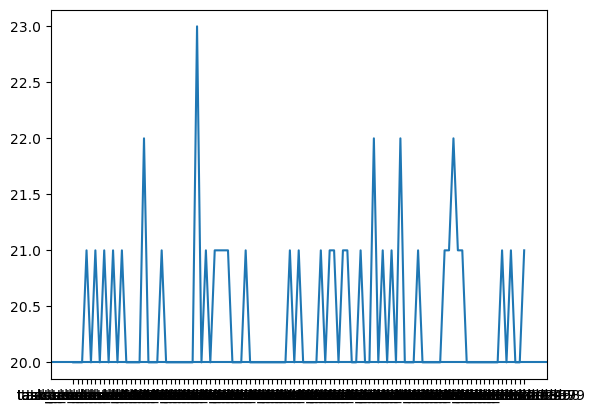

In [311]:
plt.plot(counts)
plt.axhline(20)